In [1]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# Define Drive / Export Paths
PROJECT_DIR = '/content/drive/MyDrive/Econ8310_Project'
VIDEO_DIR = os.path.join(PROJECT_DIR, 'videos')
XML_DIR = os.path.join(PROJECT_DIR, 'annotations')
MODEL_SAVE = os.path.join(PROJECT_DIR, 'baseball_model_best.pt')
FINAL_SAVE = os.path.join(PROJECT_DIR, 'baseball_model_final.pt')

videos = [f for f in os.listdir(VIDEO_DIR) if f.endswith('.mov') or f.endswith('.mp4')]
annotations = [f for f in os.listdir(XML_DIR) if f.endswith('.xml')]

print(f'Drive mounted successfully')
print(f' Videos found : {len(videos)}')
print(f' Annotations found : {len(annotations)}')

Mounted at /content/drive
Drive mounted successfully
  Videos found      : 38
  Annotations found : 38


In [14]:
# Data Loader
import torch
import torchvision
import xml.etree.ElementTree as ET
import cv2
from torch.utils.data import Dataset, DataLoader

IMG_SIZE = 224
BATCH_SIZE = 2
MIN_FRAMES = 10
REQUIRE_MOVING = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_moving(box):
    """Reads moving from CVAT child element"""
    try:
        attr_el = box.find("attribute[@name='moving']")
        if attr_el is not None:
            return attr_el.text.strip().lower() == 'true'
        return False
    except Exception:
        return False


def parse_xml_annotations(xml_path):
    """Returns {frame_num: [(xtl_n, ytl_n, xbr_n, ybr_n, is_moving), ...]}"""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    height = float(root.find('.//original_size/height').text)
    width = float(root.find('.//original_size/width').text)
    frame_boxes = {}
    for track in root.findall('track'):
        for box in track.findall('box'):
            if box.attrib.get('outside', '0') == '1':
                continue
            frame_num = int(box.attrib['frame'])
            xtl = float(box.attrib['xtl'])
            ytl = float(box.attrib['ytl'])
            xbr = float(box.attrib['xbr'])
            ybr = float(box.attrib['ybr'])
            if xbr <= xtl or ybr <= ytl:  # skips degenerate boxes
                continue
            xtl_n = max(0.0, min(1.0, xtl / width))
            ytl_n = max(0.0, min(1.0, ytl / height))
            xbr_n = max(0.0, min(1.0, xbr / width))
            ybr_n = max(0.0, min(1.0, ybr / height))
            is_moving = get_moving(box)
            if frame_num not in frame_boxes:
                frame_boxes[frame_num] = []
            frame_boxes[frame_num].append((xtl_n, ytl_n, xbr_n, ybr_n, is_moving))
    return frame_boxes

def count_xml_quality(xml_path):
    """Pre-scan: returns (n_frames, n_moving_boxes)."""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except ET.ParseError:
        return 0, 0
    frame_set = set()
    moving_count = 0
    for track in root.findall('track'):
        for box in track.findall('box'):
            if box.attrib.get('outside', '0') == '1':
                continue
            frame_set.add(int(box.attrib['frame']))
            if get_moving(box):
                moving_count += 1
    return len(frame_set), moving_count

def find_video_xml_pairs(video_dir, xml_dir):
    """Discovers matched pairs and applies quality filters."""
    video_extensions = {'.mov', '.mp4'}
    video_map = {}
    for f in os.listdir(video_dir):
        stem, ext = os.path.splitext(f)
        if ext.lower() in video_extensions:
            video_map[stem] = os.path.join(video_dir, f)

    pairs = []
    cut_low = []
    cut_no_moving = []

    for f in sorted(os.listdir(xml_dir)):
        if not f.lower().endswith('.xml'):
            continue
        stem = os.path.splitext(f)[0]
        xml_path = os.path.join(xml_dir, f)
        if stem not in video_map:
            continue
        n_frames, n_moving = count_xml_quality(xml_path)
        if n_frames < MIN_FRAMES:
            cut_low.append(f)
            continue
        if REQUIRE_MOVING and n_moving == 0:
            cut_no_moving.append(f)
            continue
        pairs.append((video_map[stem], xml_path))

    print(f' Cut (< {MIN_FRAMES} frames) : {len(cut_low)}')
    print(f' Cut (0 moving boxes) : {len(cut_no_moving)}')
    print(f' Pairs passed : {len(pairs)}')
    return sorted(pairs)


class BaseballVideoDataset(Dataset):

    def __init__(self, video_xml_pairs, img_size=224):
        self.img_size = img_size
        self.samples = []
        total_frames = total_boxes = total_moving = 0

        print(f'\nLoading {len(video_xml_pairs)} video/annotation pair(s)...\n')

        for video_path, xml_path in video_xml_pairs:
            video_name = os.path.basename(video_path)
            try:
                frame_boxes = parse_xml_annotations(xml_path)
            except Exception as e:
                print(f'  WARNING XML error {video_name}: {e} - skipping')
                continue
            if not frame_boxes:
                continue

            cap = cv2.VideoCapture(video_path)
            if not cap.isOpened():
                print(f'  WARNING COULD NOT OPEN {video_name} - skipping')
                continue

            frame_num = loaded = v_boxes = v_moving = 0
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                if frame_num in frame_boxes:
                    boxes = frame_boxes[frame_num]
                    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frame_resized = cv2.resize(frame_rgb, (img_size, img_size))
                    self.samples.append((frame_resized, boxes))
                    loaded  += 1
                    v_boxes += len(boxes)
                    v_moving += sum(1 for b in boxes if b[4])
                frame_num += 1
            cap.release()

            total_frames += loaded
            total_boxes += v_boxes
            total_moving += v_moving
            print(f' {video_name:<42} frames={loaded:>4} boxes={v_boxes:>5} moving={v_moving:>4}')

        print(f'\n{"="*55}')
        print(f' Total frames : {total_frames:,}')
        print(f' Total boxes : {total_boxes:,}')
        print(f' Moving boxes : {total_moving:,}')
        print(f' Stationary boxes: {total_boxes - total_moving:,}')
        print(f'{"="*55}\n')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame, boxes = self.samples[idx]
        image = torch.tensor(frame, dtype=torch.float32).permute(2, 0, 1) / 255.0
        boxes_pixels = []
        moving_flags = []
        for (xtl, ytl, xbr, ybr, is_moving) in boxes:
            boxes_pixels.append([
                xtl * self.img_size, ytl * self.img_size,
                xbr * self.img_size, ybr * self.img_size
            ])
            moving_flags.append(is_moving)
        target = {
            'boxes': torch.tensor(boxes_pixels, dtype=torch.float32),
            'labels': torch.ones(len(boxes_pixels), dtype=torch.int64),
            'image_id': torch.tensor(idx),
            'area': torch.tensor(
                [(b[2]-b[0])*(b[3]-b[1]) for b in boxes_pixels],
                dtype=torch.float32),
            'iscrowd': torch.zeros(len(boxes_pixels), dtype=torch.int64),
            'moving': torch.tensor(moving_flags, dtype=torch.bool),
        }
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


# Run the loader
print('Scanning for matched video/XML pairs...')
pairs = find_video_xml_pairs(VIDEO_DIR, XML_DIR)
full_dataset = BaseballVideoDataset(pairs, img_size=IMG_SIZE)

n = len(full_dataset)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = torch.utils.data.random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

print(f'Train : {len(train_ds):,} frames (70%)')
print(f'Val : {len(val_ds):,} frames (15%)')
print(f'Test : {len(test_ds):,} frames (15%)')
print('Data loader ready')

Scanning for matched video/XML pairs...
 Cut (< 10 frames) : 0
 Cut (0 moving boxes) : 0
 Pairs passed : 38

Loading 38 video/annotation pair(s)...

 IMG_0040.mov                               frames=  57 boxes=   59 moving=   2
 IMG_0041.mov                               frames=  50 boxes=   52 moving=   2
 IMG_0042.mov                               frames=  52 boxes=   54 moving=   2
 IMG_0043.mov                               frames=  48 boxes=   51 moving=   3
 IMG_0044.mov                               frames=  56 boxes=   57 moving=   1
 IMG_0045.mov                               frames=  60 boxes=   62 moving=   2
 IMG_0046.mov                               frames=  54 boxes=   56 moving=   2
 IMG_0047.mov                               frames=  48 boxes=   49 moving=   1
 IMG_0074.mov                               frames= 100 boxes= 1861 moving=  61
 IMG_0075.mov                               frames=  80 boxes= 1865 moving=  79
 IMG_0076.mov                               frames=

In [5]:
# 4 Model Build
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

def get_baseball_model(num_classes=2):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

NUM_CLASSES = 2
model = get_baseball_model(NUM_CLASSES)
model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model loaded on {device}')
print(f'Trainable parameters: {trainable:,}')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 183MB/s]


Model loaded on cuda
Trainable parameters: 41,076,761


In [6]:
# 5 Train the Model
import gc

LEARNING_RATE = 0.001
EPOCHS = 10
CONF_THRESHOLD = 0.5

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, momentum=0.9, weight_decay=0.0005
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=3, gamma=0.1
)

gc.collect()
torch.cuda.empty_cache()

best_val_loss = float('inf')
train_losses = []
val_losses = []

print(f'Training {EPOCHS} epochs on {device} | LR={LEARNING_RATE} | Batch={BATCH_SIZE}')
print('=' * 60)

for epoch in range(EPOCHS):

    # Training
    model.train()
    epoch_train_loss = 0.0
    for batch_idx, (images, targets) in enumerate(train_loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items() if k != 'moving'}
                   for t in targets]
        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_train_loss += losses.item()
        if batch_idx % 20 == 0:
            print(f'  Epoch [{epoch+1}/{EPOCHS}] '
                  f'Batch [{batch_idx+1}/{len(train_loader)}] '
                  f'Loss: {losses.item():.4f}')

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.train()  # keep train mode to get losses
    epoch_val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items() if k != 'moving'}
                       for t in targets]
            loss_dict = model(images, targets)
            epoch_val_loss += sum(loss for loss in loss_dict.values()).item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    lr_scheduler.step()

    print(f'\nEpoch [{epoch+1}/{EPOCHS}] '
          f'Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}', end='')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch' : epoch + 1,
            'model_state_dict' : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss' : avg_train_loss,
            'val_loss' : avg_val_loss,
            'num_classes' : NUM_CLASSES,
            'img_size' : IMG_SIZE,
        }, MODEL_SAVE)
        print(f' <- Best model saved')
    else:
        print()
    print('-' * 60)

torch.save({
    'epoch' : EPOCHS,
    'model_state_dict': model.state_dict(),
    'train_losses' : train_losses,
    'val_losses' : val_losses,
    'num_classes' : NUM_CLASSES,
    'img_size' : IMG_SIZE,
}, FINAL_SAVE)

print(f'\nTraining complete!')
print(f'Best val loss : {best_val_loss:.4f}')
print(f'Best model  -> {MODEL_SAVE}')
print(f'Final model -> {FINAL_SAVE}')

Training 10 epochs on cuda | LR=0.001 | Batch=2
  Epoch [1/10] Batch [1/829] Loss: 4.3263
  Epoch [1/10] Batch [21/829] Loss: 0.7434
  Epoch [1/10] Batch [41/829] Loss: 0.9297
  Epoch [1/10] Batch [61/829] Loss: 1.0454
  Epoch [1/10] Batch [81/829] Loss: 0.2597
  Epoch [1/10] Batch [101/829] Loss: 0.8196
  Epoch [1/10] Batch [121/829] Loss: 0.1616
  Epoch [1/10] Batch [141/829] Loss: 0.5631
  Epoch [1/10] Batch [161/829] Loss: 0.9924
  Epoch [1/10] Batch [181/829] Loss: 0.1787
  Epoch [1/10] Batch [201/829] Loss: 0.3316
  Epoch [1/10] Batch [221/829] Loss: 0.5514
  Epoch [1/10] Batch [241/829] Loss: 0.1086
  Epoch [1/10] Batch [261/829] Loss: 0.4284
  Epoch [1/10] Batch [281/829] Loss: 0.9914
  Epoch [1/10] Batch [301/829] Loss: 0.0502
  Epoch [1/10] Batch [321/829] Loss: 0.5188
  Epoch [1/10] Batch [341/829] Loss: 0.5041
  Epoch [1/10] Batch [361/829] Loss: 0.5939
  Epoch [1/10] Batch [381/829] Loss: 0.1265
  Epoch [1/10] Batch [401/829] Loss: 0.6044
  Epoch [1/10] Batch [421/829] Los

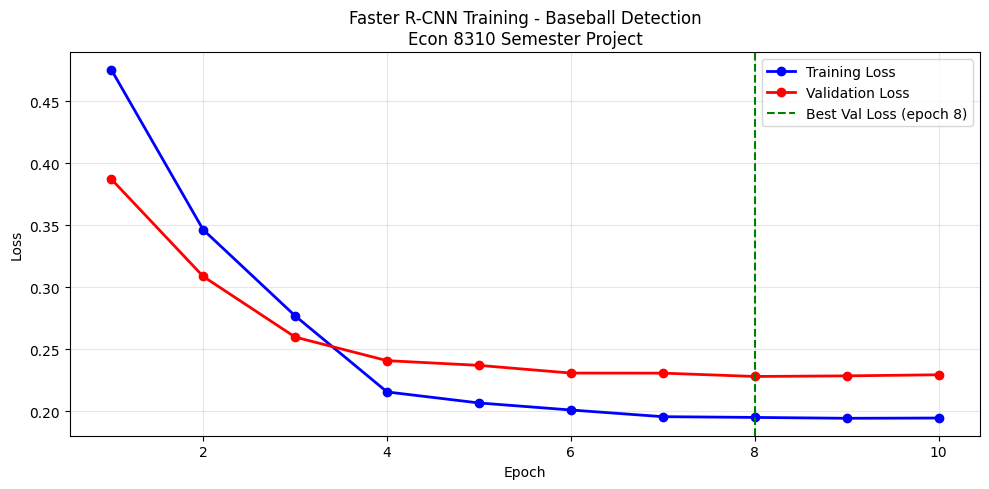

Training curves saved to /content/drive/MyDrive/Econ8310_Project/training_curves.png


In [9]:
# Plot Training Curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses, 'b-o', label='Training Loss', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses, 'r-o', label='Validation Loss', linewidth=2)
best_epoch = val_losses.index(min(val_losses)) + 1
plt.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best Val Loss (epoch {best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Faster R-CNN Training - Baseball Detection\nEcon 8310 Semester Project')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(PROJECT_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Training curves saved to {plot_path}')

In [8]:
# Inference Summary
loaded_model = get_baseball_model(NUM_CLASSES)
checkpoint = torch.load(MODEL_SAVE, map_location=device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.to(device)
loaded_model.eval()

print(f'Best model loaded (saved at epoch {checkpoint["epoch"]})')
print(f'Val loss at save : {checkpoint["val_loss"]:.4f}\n')

sample_video = sorted([
    os.path.join(VIDEO_DIR, f) for f in os.listdir(VIDEO_DIR)
    if f.endswith('.mov') or f.endswith('.mp4')
])[0]

print(f'Running inference on: {os.path.basename(sample_video)}')

cap = cv2.VideoCapture(sample_video)
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
frame_resized = cv2.resize(frame_rgb, (IMG_SIZE, IMG_SIZE))
input_tensor = torch.tensor(frame_resized, dtype=torch.float32).permute(2, 0, 1) / 255.0

with torch.no_grad():
    predictions = loaded_model([input_tensor.to(device)])

pred = predictions[0]
high_conf = pred['scores'] > CONF_THRESHOLD

print(f'\nInference Results (confidence > {CONF_THRESHOLD}):')
print(f'Baseballs detected: {high_conf.sum().item()}')
print(f'All scores: {[f"{s:.3f}" for s in pred["scores"].tolist()]}')
print(f'\nModel loads and runs inference without retraining')

Best model loaded (saved at epoch 8)
Val loss at save : 0.2281

Running inference on: IMG_0040.mov

Inference Results (confidence > 0.5):
  Baseballs detected : 1
  All scores         : ['0.999']

Model loads and runs inference without retraining


In [17]:
# Evaluating the Model with mAP and IoU

"""
Computes the standard object detection metrics on the held-out test set
(the 15% the model never saw during training).

Metrics computed:
    - mAP @ IoU=0.50 -  Standard "PASCAL VOC" detection metric
    - mAP @ IoU=0.50-0.95 - Strict "COCO" metric (averaged across thresholds)
    - Mean IoU - Average overlap quality of correct detections
    - Detection counts - True positives, false positives, false negatives
"""
!pip install -q torchmetrics

from torchmetrics.detection import MeanAveragePrecision
from torchvision.ops import box_iou
import numpy as np

# Make sure model is loaded and in eval mode
loaded_model = get_baseball_model(NUM_CLASSES)
checkpoint = torch.load(MODEL_SAVE, map_location=device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.to(device)
loaded_model.eval()

print(f'Model loaded - best epoch: {checkpoint["epoch"]}')
print(f'Validation loss at save: {checkpoint["val_loss"]:.4f}')
print(f'\nEvaluating on {len(test_loader.dataset)} test frames...\n')


# mAP metric (uses official torchvision/COCO implementation)
mAP_metric = MeanAveragePrecision(iou_type='bbox')


# IoU + counting accumulators
all_ious = []  # IoU values for matched (TP) detections
total_gt = 0  # ground-truth boxes seen
true_pos = 0  # predictions that match a GT box at IoU >= 0.5
false_pos = 0  # high-confidence predictions with no matching GT
false_neg = 0  # GT boxes with no matching prediction

# Track moving vs stationary separately for the executive summary
moving_tp = 0
moving_total = 0
station_tp = 0
station_total = 0

CONF_THRESHOLD = 0.5
IOU_THRESHOLD  = 0.5

with torch.no_grad():
    for batch_idx, (images, targets) in enumerate(test_loader):
        images = [img.to(device) for img in images]

        # Run model to list of dicts with boxes/labels/scores per image
        predictions = loaded_model(images)

        # Format for torchmetrics - needs CPU tensors
        preds_for_map = []
        targs_for_map = []

        for pred, target in zip(predictions, targets):
            # Filter predictions by confidence threshold
            keep = pred['scores'] > CONF_THRESHOLD
            pred_boxes = pred['boxes'][keep].cpu()
            pred_scores = pred['scores'][keep].cpu()
            pred_labels = pred['labels'][keep].cpu()

            preds_for_map.append({
                'boxes' : pred_boxes,
                'scores': pred_scores,
                'labels': pred_labels,
            })

            gt_boxes = target['boxes'].cpu()
            gt_labels = target['labels'].cpu()
            gt_moving = target.get('moving', torch.zeros(len(gt_boxes), dtype=torch.bool)).cpu()

            targs_for_map.append({
                'boxes' : gt_boxes,
                'labels': gt_labels,
            })

            # Compute IoU + per-class counts manually
            total_gt      += len(gt_boxes)
            moving_total  += int(gt_moving.sum().item())
            station_total += int((~gt_moving).sum().item())

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                # IoU matrix: [n_preds, n_gt]
                iou_matrix = box_iou(pred_boxes, gt_boxes)

                # For each GT, find best matching prediction
                matched_gt   = set()
                matched_pred = set()

                # Greedy match: highest-IoU pairs first
                pairs = []
                for i in range(len(pred_boxes)):
                    for j in range(len(gt_boxes)):
                        if iou_matrix[i, j] >= IOU_THRESHOLD:
                            pairs.append((iou_matrix[i, j].item(), i, j))
                pairs.sort(reverse=True)

                for iou_val, i, j in pairs:
                    if i in matched_pred or j in matched_gt:
                        continue
                    matched_pred.add(i)
                    matched_gt.add(j)
                    all_ious.append(iou_val)
                    true_pos += 1

                    # Track moving vs stationary
                    if gt_moving[j]:
                        moving_tp += 1
                    else:
                        station_tp += 1

                false_pos += len(pred_boxes) - len(matched_pred)
                false_neg += len(gt_boxes)   - len(matched_gt)
            else:
                false_pos += len(pred_boxes)
                false_neg += len(gt_boxes)

        # Update mAP metric
        mAP_metric.update(preds_for_map, targs_for_map)

        if batch_idx % 30 == 0:
            print(f'Batch [{batch_idx+1}/{len(test_loader)}] processed')

print('\nComputing final metrics...')
mAP_results = mAP_metric.compute()


# FINAL SUMMARY REPORT
mean_iou = np.mean(all_ious) if all_ious else 0.0
precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0.0
recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0.0
f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0.0

moving_recall = moving_tp / moving_total   if moving_total   > 0 else 0.0
station_recall = station_tp / station_total if station_total > 0 else 0.0

print(f'TEST SET EVALUATION: {len(test_loader.dataset)} held-out frames')

print(f'\nObject Detection Metrics (standard)')
print(f'mAP @ IoU=0.50: {mAP_results["map_50"].item():.4f}')
print(f'mAP @ IoU=0.75: {mAP_results["map_75"].item():.4f}')
print(f'mAP @ IoU=0.50-0.95: {mAP_results["map"].item():.4f}   (COCO standard)')

print(f'\nBounding Box Quality')
print(f'Mean IoU (correct): {mean_iou:.4f}')
print(f'Box quality range: {min(all_ious):.3f} - {max(all_ious):.3f}' if all_ious else '  (no correct detections)')

print(f'\nDetection Counts (conf > {CONF_THRESHOLD}, IoU >= {IOU_THRESHOLD}) ──')
print(f'Ground-truth boxes: {total_gt:,}')
print(f'True positives: {true_pos:,}')
print(f'False positives: {false_pos:,}')
print(f'False negatives: {false_neg:,}')

print(f'\nClassification-style Metrics')
print(f'Precision: {precision:.4f}   (of detections, % correct)')
print(f'Recall: {recall:.4f}   (of actual balls, % found)')
print(f'F1 Score: {f1:.4f}')

print(f'\nMoving vs Stationary Performance')
print(f'Moving balls found: {moving_tp:,} / {moving_total:,} ({moving_recall*100:.1f}%)')
print(f'Stationary found: {station_tp:,} / {station_total:,} ({station_recall*100:.1f}%)')


# Save results to Drive for easy reference
import json
results_path = os.path.join(PROJECT_DIR, 'evaluation_results.json')
with open(results_path, 'w') as f:
    json.dump({
        'best_epoch' : int(checkpoint['epoch']),
        'best_val_loss' : float(checkpoint['val_loss']),
        'test_frames' : len(test_loader.dataset),
        'mAP_50' : float(mAP_results['map_50'].item()),
        'mAP_75' : float(mAP_results['map_75'].item()),
        'mAP_50_95' : float(mAP_results['map'].item()),
        'mean_iou' : float(mean_iou),
        'precision' : float(precision),
        'recall' : float(recall),
        'f1' : float(f1),
        'true_positives' : int(true_pos),
        'false_positives' : int(false_pos),
        'false_negatives' : int(false_neg),
        'total_gt' : int(total_gt),
        'moving_recall' : float(moving_recall),
        'station_recall' : float(station_recall),
    }, f, indent=2)
print(f'\nResults saved to: {results_path}')

Model loaded - best epoch: 8
Validation loss at save: 0.2281

Evaluating on 356 test frames...

Batch [1/178] processed
Batch [31/178] processed
Batch [61/178] processed
Batch [91/178] processed
Batch [121/178] processed
Batch [151/178] processed

Computing final metrics...
TEST SET EVALUATION: 356 held-out frames

Object Detection Metrics (standard)
mAP @ IoU=0.50: 0.8299
mAP @ IoU=0.75: 0.6778
mAP @ IoU=0.50-0.95: 0.6048   (COCO standard)

Bounding Box Quality
Mean IoU (correct): 0.8605
Box quality range: 0.502 - 0.992

Detection Counts (conf > 0.5, IoU >= 0.5) ──
Ground-truth boxes: 3,479
True positives: 2,933
False positives: 639
False negatives: 546

Classification-style Metrics
Precision: 0.8211   (of detections, % correct)
Recall: 0.8431   (of actual balls, % found)
F1 Score: 0.8319

Moving vs Stationary Performance
Moving balls found: 104 / 201 (51.7%)
Stationary found: 2,829 / 3,278 (86.3%)

Results saved to: /content/drive/MyDrive/Econ8310_Project/evaluation_results.json
